## Импорт необходимых библиотек и модулей.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig
)
from torch.optim import AdamW

# Опциональный импорт PEFT для LoRA (обработка несовместимости версий)
try:
    from peft import LoraConfig, get_peft_model, TaskType
    PEFT_AVAILABLE = True
except ImportError as e:
    PEFT_AVAILABLE = False
    _PEFT_IMPORT_ERROR = str(e)
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

import torch._dynamo

torch._dynamo.config.suppress_errors = True

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка датасета.

In [2]:
train_df = pd.read_csv('train_user_preference.csv')
test_df = pd.read_csv('test_user_preference.csv')

train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57477 non-null  int64 
 1   model_a         57477 non-null  object
 2   model_b         57477 non-null  object
 3   prompt          57477 non-null  object
 4   response_a      57477 non-null  object
 5   response_b      57477 non-null  object
 6   winner_model_a  57477 non-null  int64 
 7   winner_model_b  57477 non-null  int64 
 8   winner_tie      57477 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          3 non-null      int64 
 1   prompt      3 non-null      object
 2   response_a  3 non-null      object
 3   response_b  3 non-null      object
dtypes: int64(1), 

In [3]:
train_df.head(3)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


In [4]:
test_df.head()

,id,prompt,response_a,response_b
0,136060,"[""I have three oranges today, I ate an orange ...","[""You have two oranges today.""]","[""You still have three oranges. Eating an oran..."
1,211333,"[""You are a mediator in a heated political deb...","[""Thank you for sharing the details of the sit...","[""Mr Reddy and Ms Blue both have valid points ..."
2,1233961,"[""How to initialize the classification head wh...","[""When you want to initialize the classificati...","[""To initialize the classification head when p..."


In [5]:
Cut_Train_df = True

col_a = 'winner_model_a'
col_b = 'winner_model_b'
col_tie = 'winner_tie'

train_df['label'] = 0 
train_df.loc[train_df[col_b] == 1, 'label'] = 1
train_df.loc[train_df[col_tie] == 1, 'label'] = 2

train_df = train_df.drop(columns=[col_a, col_b, col_tie])
train_df = train_df.drop(columns=['model_a', 'model_b'])
train_df.columns = ['id', 'prompt', 'response1', 'response2', 'label']

if Cut_Train_df:
    train_df = train_df.sample(n=8000, random_state=42).reset_index(drop=True)


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         8000 non-null   int64 
 1   prompt     8000 non-null   object
 2   response1  8000 non-null   object
 3   response2  8000 non-null   object
 4   label      8000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 312.6+ KB


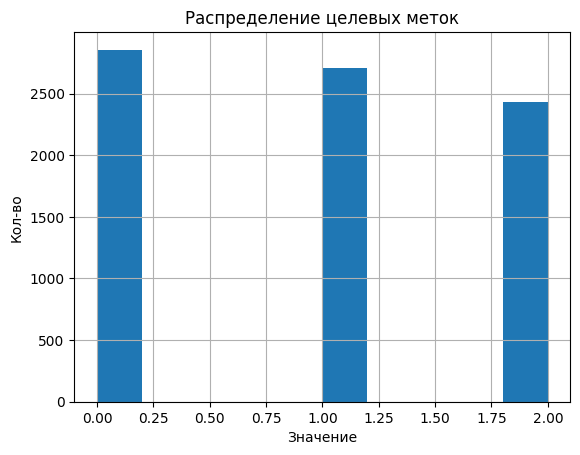

In [7]:
fig = pd.Series(train_df["label"]).hist()
plt.title('Распределение целевых меток')
plt.xlabel('Значение')
plt.ylabel('Кол-во')
plt.show()

In [8]:
test_df.columns = ['id', 'prompt', 'response1', 'response2']

In [9]:
num_answers = 2

train_prompts = train_df['prompt'].tolist()
train_answer_cols = [f'response{i+1}' for i in range(num_answers)]
train_answers = [[row[col] for col in train_answer_cols] for _, row in train_df.iterrows()]
train_labels = train_df['label'].tolist()


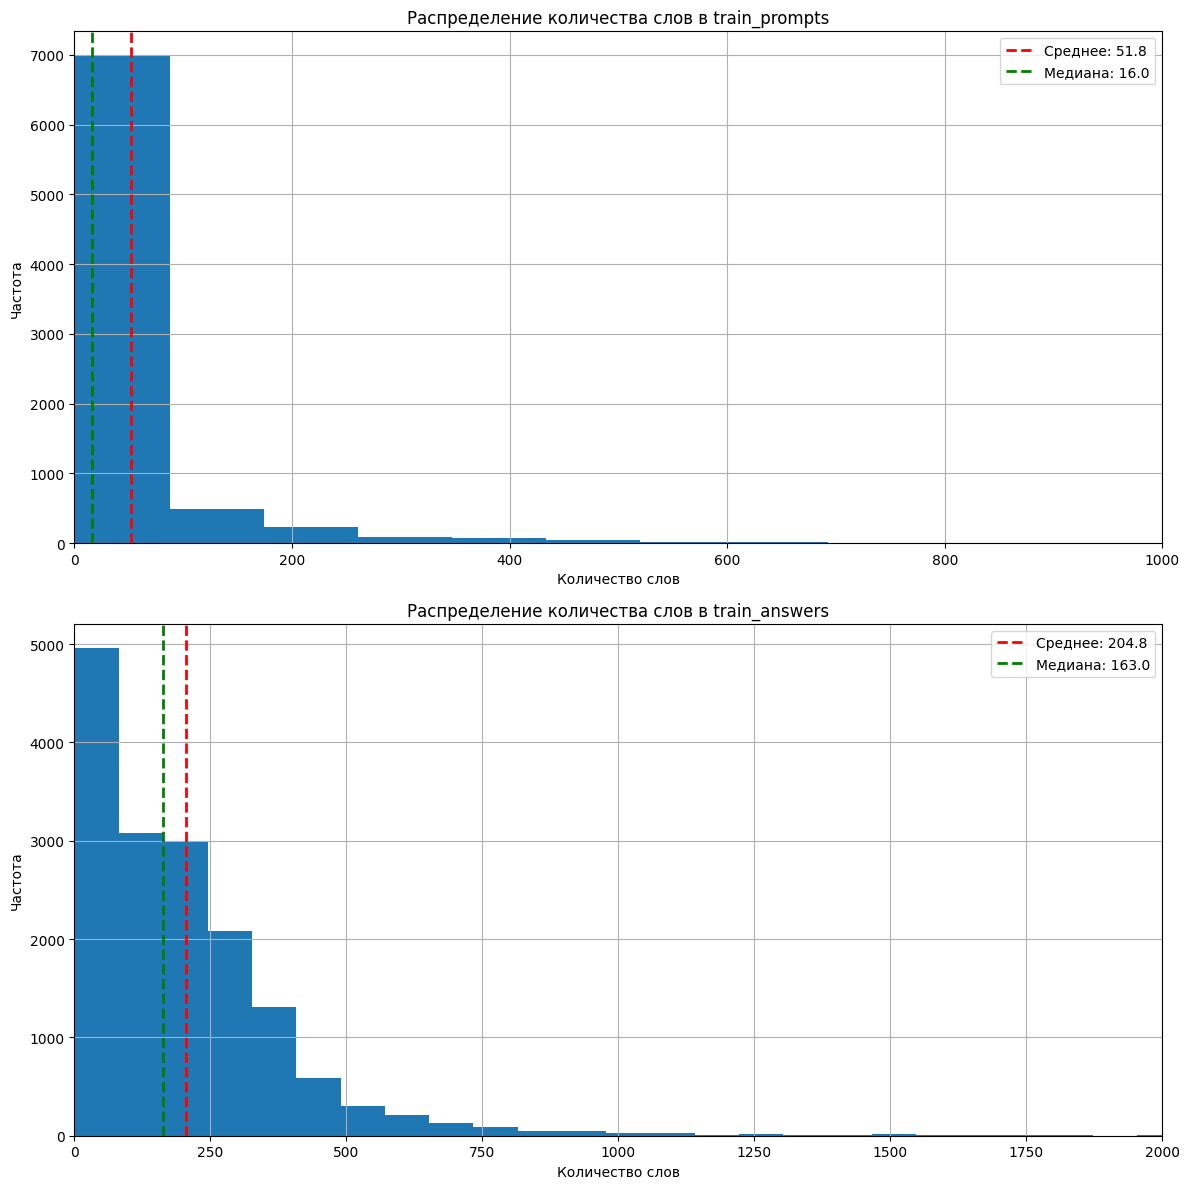

In [10]:
prompt_word_counts = [len(str(prompt).split()) for prompt in train_prompts]

answer_word_counts = []
for answer_pair in train_answers:
    for answer in answer_pair:
        answer_word_counts.append(len(str(answer).split()))

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].hist(prompt_word_counts, bins=50)
axes[0].set_title('Распределение количества слов в train_prompts')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(0, 1000)
axes[0].grid(True)
axes[0].axvline(np.mean(prompt_word_counts), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(prompt_word_counts):.1f}')
axes[0].axvline(np.median(prompt_word_counts), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(prompt_word_counts):.1f}')
axes[0].legend()

axes[1].hist(answer_word_counts, bins=50)
axes[1].set_title('Распределение количества слов в train_answers')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')
axes[1].set_xlim(0, 2000)
axes[1].grid(True)
axes[1].axvline(np.mean(answer_word_counts), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(answer_word_counts):.1f}')
axes[1].axvline(np.median(answer_word_counts), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(answer_word_counts):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
test_prompts = test_df['prompt'].tolist()
test_answer_cols = [f'response{i+1}' for i in range(num_answers)]
test_answers = [[row[col] for col in test_answer_cols] for _, row in test_df.iterrows()]

### Создаем класс pre-trained модели и задаем в нем параметры обучения.

Класс поддерживает работу с произвольным количеством ответов моделей на каждый запрос. 
- По умолчанию используется 2 ответа
- Можно указать любое количество ответов через параметр `num_answers`
- Ответы передаются в виде списка списков: `[[ans1, ans2, ...], [ans1, ans2, ...], ...]`
- Метки: 0, 1, 2, ..., N-1 (где N - количество ответов, 0 - первый ответ, 1 - второй, и т.д.)

In [12]:
class ModelAnswerClassifier:
    """
    Класс для дообучения предобученных моделей для классификации последовательностей.
    Классифицирует, какой из N ответов модели лучше для данного пользовательского запроса.
    """
    
    def __init__(
        self,
        model_name: str = "distilbert-base-uncased",
        num_answers: int = 2,
        num_labels: int = None,
        max_length: int = 512,
        batch_size: int = 16,
        learning_rate: float = 2e-5,
        num_epochs: int = 3,
        weight_decay: float = 0.01,
        warmup_steps: int = 0,
        device: str = None,
        random_seed: int = 42,
        dropout: float = 0,
        freeze_params: bool = False,
        # Параметры LoRA (при use_lora=True)
        use_lora: bool = False,
        lora_r: int = 8,
        lora_alpha: int = 16,
        lora_dropout: float = 0.1,
        lora_target_modules: list = None,
        lora_bias: str = "none",
        lora_modules_to_save: list = None,
    ):
        """
        Инициализирует классификатор с параметрами модели и обучения.
        
        Args:
            model_name: Имя модели HuggingFace
            num_answers: Количество ответов моделей на каждый запрос (по умолчанию: 2)
            num_labels: Количество меток классификации (по умолчанию: равно num_answers)
            max_length: Максимальная длина последовательности для токенизации
            batch_size: Размер батча для обучения
            learning_rate: Скорость обучения для оптимизатора
            num_epochs: Количество эпох обучения
            weight_decay: Затухание весов для оптимизатора
            warmup_steps: Количество шагов разогрева для планировщика скорости обучения
            device: Устройство для использования ('cuda', 'cpu', или None для автоматического определения)
            random_seed: Случайное зерно для воспроизводимости
            dropout: Процент "выключенных" нейронов при обучении
            freeze_params: "Заморозка" весов модели, обучение только классификационного слоя
            use_lora: Включить LoRA-адаптеры (требует peft)
            lora_r: Ранг LoRA-матриц
            lora_alpha: Масштабирующий коэффициент LoRA (обычно 2*r)
            lora_dropout: Dropout для LoRA-слоёв
            lora_target_modules: Модули для LoRA (None = авто для DistilBERT/BERT)
            lora_bias: Тип bias для LoRA ("none", "all", "lora_only")
            lora_modules_to_save: Доп. модули для обучения (напр. classifier)
        """
        self.model_name = model_name
        self.num_answers = num_answers
        self.num_labels = num_labels if num_labels is not None else num_answers
        self.max_length = max_length
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.weight_decay = weight_decay
        self.warmup_steps = warmup_steps
        self.random_seed = random_seed
        self.dropout = dropout
        self.freeze_params = freeze_params
        
        # Параметры LoRA
        self.use_lora = use_lora
        self.lora_r = lora_r
        self.lora_alpha = lora_alpha
        self.lora_dropout = lora_dropout
        self.lora_target_modules = lora_target_modules
        self.lora_bias = lora_bias
        self.lora_modules_to_save = lora_modules_to_save
        
        # Установка устройства
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        
        # Установка случайных зерен для воспроизводимости
        self._set_seed(random_seed)
        
        # Инициализация модели и токенизатора (будут загружены при вызове prepare_model)
        self.tokenizer = None
        self.model = None
        self.optimizer = None
        self.scheduler = None
        
    def _set_seed(self, seed):
        """
        Устанавливает случайные зерна для воспроизводимости.
        """
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    
    def prepare_model(self):
        """
        Загружает и инициализирует модель и токенизатор.
        """
        print(f"Загрузка модели: {self.model_name}")
        print(f"Используемое устройство: {self.device}")
        print(f"Количество ответов на запрос: {self.num_answers}")
        print(f"Количество меток классификации: {self.num_labels}")
        
        # Загрузка токенизатора
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        
        # Загрузка конфигурации модели и настройка для классификации
        config = AutoConfig.from_pretrained(self.model_name)
        config.num_labels = self.num_labels
        config.dropout = self.dropout
        
        # Загрузка модели
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            config=config
        )
        
        # Применение LoRA (если включено)
        if self.use_lora:
            if not PEFT_AVAILABLE:
                raise ImportError(
                    f"LoRA включена (use_lora=True), но PEFT недоступна. "
                    f"Установите: pip install peft. Ошибка: {_PEFT_IMPORT_ERROR}"
                )
            # target_modules по умолчанию: DistilBERT (q_lin, v_lin); BERT: ["query", "value"]
            target_modules = self.lora_target_modules
            if target_modules is None:
                target_modules = ["q_lin", "v_lin"]
            modules_to_save = self.lora_modules_to_save
            if modules_to_save is None:
                modules_to_save = ["classifier", "pre_classifier"]
            lora_config = LoraConfig(
                task_type=TaskType.SEQ_CLS,
                r=self.lora_r,
                lora_alpha=self.lora_alpha,
                lora_dropout=self.lora_dropout,
                target_modules=target_modules,
                bias=self.lora_bias,
                modules_to_save=modules_to_save,
            )
            self.model = get_peft_model(self.model, lora_config)
            print(f"LoRA включена: r={self.lora_r}, alpha={self.lora_alpha}, "
                  f"target_modules={target_modules}, modules_to_save={modules_to_save}")
        elif self.freeze_params:
            for param in self.model.base_model.parameters():
                param.requires_grad = False

        self.model.to(self.device)
        
        print("Модель успешно загружена.")
        print(f"Всего параметров: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Обучаемых параметров: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")
    
    def prepare_optimizer(self, num_training_steps: int = None):
        """
        Подготавливает оптимизатор и планировщик скорости обучения.
        """
        if self.model is None:
            raise ValueError("Модель должна быть подготовлена сначала. Вызовите prepare_model()")
        
        # Подготовка оптимизатора (при LoRA/freeze только обучаемые параметры)
        no_decay = ["bias", "LayerNorm.weight"]
        
        if self.freeze_params or self.use_lora:
            trainable_params = [p for p in self.model.named_parameters() if p[1].requires_grad]
            
            if len(trainable_params) == 0:
                raise ValueError("Нет обучаемых параметров! Проверьте freeze_params и prepare_model")
            
            optimizer_grouped_parameters = [
                {
                    "params": [p for n, p in trainable_params 
                            if not any(nd in n for nd in no_decay)],
                    "weight_decay": self.weight_decay,
                },
                {
                    "params": [p for n, p in trainable_params 
                            if any(nd in n for nd in no_decay)],
                    "weight_decay": 0.0,
                },
            ]
        else:
            optimizer_grouped_parameters = [
                {
                    "params": [p for n, p in self.model.named_parameters() 
                            if not any(nd in n for nd in no_decay)],
                    "weight_decay": self.weight_decay,
                },
                {
                    "params": [p for n, p in self.model.named_parameters() 
                            if any(nd in n for nd in no_decay)],
                    "weight_decay": 0.0,
                },
            ]
        
        self.optimizer = AdamW(
            optimizer_grouped_parameters,
            lr=self.learning_rate
        )
        
        # Подготовка планировщика, если указаны шаги разогрева
        if num_training_steps and self.warmup_steps > 0:
            from transformers import get_linear_schedule_with_warmup
            self.scheduler = get_linear_schedule_with_warmup(
                self.optimizer,
                num_warmup_steps=self.warmup_steps,
                num_training_steps=num_training_steps
            )
        else:
            self.scheduler = None
    
    def create_dataset(self, prompts, answers, labels=None):
        """
        Создает набор данных PyTorch.
        
        Args:
            prompts: Список пользовательских запросов
            answers: Список списков ответов моделей. Каждый внутренний список содержит N ответов.
                     Например, для 2 ответов: [[ans1_1, ans2_1], [ans1_2, ans2_2], ...]
                     Для 3 ответов: [[ans1_1, ans2_1, ans3_1], [ans1_2, ans2_2, ans3_2], ...]
            labels: Список меток (0, 1, ..., N-1, указывающий, какой ответ лучше)
                    Если None, возвращает набор данных без меток (для инференса)
        
        Returns:
            Объект Dataset
        """
        if self.tokenizer is None:
            raise ValueError("Токенизатор не подготовлен. Вызови prepare_model()")
        
        # Проверка количества ответов
        if len(answers) == 0:
            raise ValueError("Список ответов не может быть пустым")
        
        if len(answers[0]) != self.num_answers:
            raise ValueError(f"Ожидается {self.num_answers} ответов на запрос, получено {len(answers[0])}")
        
        # Проверка соответствия длин
        if len(prompts) != len(answers):
            raise ValueError(f"Количество запросов ({len(prompts)}) не совпадает с количеством наборов ответов ({len(answers)})")
        
        if labels is not None and len(labels) != len(prompts):
            raise ValueError(f"Количество меток ({len(labels)}) не совпадает с количеством запросов ({len(prompts)})")
        
        class AnswerDataset(Dataset):
            def __init__(self, prompts, answers, labels, tokenizer, max_length, num_answers):
                self.prompts = prompts
                self.answers = answers
                self.labels = labels
                self.tokenizer = tokenizer
                self.max_length = max_length
                self.num_answers = num_answers
            
            def __len__(self):
                return len(self.prompts)
            
            def __getitem__(self, idx):
                prompt = str(self.prompts[idx])
                answer_list = [str(ans) for ans in self.answers[idx]]
                
                # Создание входного текста: prompt [SEP] answer1 [SEP] answer2 [SEP] ... [SEP] answerN
                text = prompt + " [SEP] " + " [SEP] ".join(answer_list)
                
                # Токенизация
                encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=self.max_length,
                    return_tensors='pt'
                )
                
                item = {
                    'input_ids': encoding['input_ids'].flatten(),
                    'attention_mask': encoding['attention_mask'].flatten()
                }
                
                if self.labels is not None:
                    item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
                
                return item
        
        return AnswerDataset(prompts, answers, labels, self.tokenizer, self.max_length, self.num_answers)
    
    def train(self, train_dataset, val_dataset=None, verbose=True):
        """
        Обучает модель на предоставленном наборе данных.
        
        Args:
            train_dataset: Обучающий набор данных
            val_dataset: Валидационный набор данных (опционально)
            verbose: Выводить ли прогресс обучения
        
        Returns:
            Словарь с историей обучения
        """
        if self.model is None:
            raise ValueError("Модель должна быть подготовлена сначала. Вызовите prepare_model()")
        
        if self.optimizer is None:
            # Вычисление количества шагов обучения
            num_training_steps = len(train_dataset) // self.batch_size * self.num_epochs
            self.prepare_optimizer(num_training_steps)
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True
        )
        
        history = {
            'train_loss': [],
            'train_accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }
        
               
        for epoch in range(self.num_epochs):
            if verbose:
                print(f"\nEpoch {epoch + 1}/{self.num_epochs}")
                print("-" * 50)
            
            self.model.train()

            total_loss = 0
            correct_predictions = 0
            total_samples = 0
            
            for batch_idx, batch in enumerate(train_loader):
                # Перемещение батча на устройство
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                # Прямой проход
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                
                loss = outputs.loss
                logits = outputs.logits
                
                # Обратный проход
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                if self.scheduler:
                    self.scheduler.step()
                
                # Статистика
                total_loss += loss.item()
                predictions = torch.argmax(logits, dim=1)
                correct_predictions += torch.sum(predictions == labels).item()
                total_samples += labels.size(0)
                
                if verbose and (batch_idx + 1) % 20 == 0:
                    print(f"Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}")
            
            # Вычисление метрик эпохи
            avg_loss = total_loss / len(train_loader)
            accuracy = correct_predictions / total_samples
            
            history['train_loss'].append(avg_loss)
            history['train_accuracy'].append(accuracy)
            
            if verbose:
                print(f"Train Loss: {avg_loss:.4f}, Train Accuracy: {accuracy:.4f}")
            
            # Валидация
            if val_dataset is not None:
                val_loss, val_accuracy = self.evaluate(val_dataset, verbose=False)
                history['val_loss'].append(val_loss)
                history['val_accuracy'].append(val_accuracy)
                
                if verbose:
                    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
                self.model.train()
        return history
    
    def evaluate(self, dataset, verbose=True):
        """
        Оценивает модель на наборе данных.
        
        Args:
            dataset: Набор данных для оценки
            verbose: Выводить ли результаты оценки
        
        Returns:
            Кортеж (потеря, точность)
        """
        if self.model is None:
            raise ValueError("Модель должна быть подготовлена сначала. Вызовите prepare_model()")
        
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        
        self.model.eval()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                
                loss = outputs.loss
                logits = outputs.logits
                
                total_loss += loss.item()
                predictions = torch.argmax(logits, dim=1)
                correct_predictions += torch.sum(predictions == labels).item()
                total_samples += labels.size(0)
        
        avg_loss = total_loss / len(dataloader)
        accuracy = correct_predictions / total_samples
        
        if verbose:
            print(f"Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
        
        return avg_loss, accuracy
    
    def predict(self, prompts, answers, return_probs=False):
        """
        Делает предсказания на новых данных.
        
        Args:
            prompts: Список пользовательских запросов
            answers: Список списков ответов моделей. Каждый внутренний список содержит N ответов.
                     Например, для 2 ответов: [[ans1, ans2], ...]
                     Для 3 ответов: [[ans1, ans2, ans3], ...]
            return_probs: Если True, возвращает вероятностные оценки
        
        Returns:
            Предсказания (и вероятности, если return_probs=True)
        """
        if self.model is None:
            raise ValueError("Модель должна быть подготовлена сначала. Вызовите prepare_model()")
        
        dataset = self.create_dataset(prompts, answers, labels=None)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        
        self.model.eval()
        all_predictions = []
        all_probs = []
        
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1)
                predictions = torch.argmax(logits, dim=1)
                
                all_predictions.extend(predictions.cpu().numpy())
                if return_probs:
                    all_probs.extend(probs.cpu().numpy())
        
        if return_probs:
            return np.array(all_predictions), np.array(all_probs)
        return np.array(all_predictions)
    
    def save_model(self, save_path):
        """Сохраняет дообученную модель и токенизатор. При use_lora=True сохраняет LoRA-адаптеры."""
        if self.model is None or self.tokenizer is None:
            raise ValueError("Модель и токенизатор должны быть подготовлены сначала")
        
        self.model.save_pretrained(save_path)
        self.tokenizer.save_pretrained(save_path)
        print(f"Модель сохранена в {save_path}" + (" (LoRA-адаптеры)" if self.use_lora else ""))
    
    def load_model(self, load_path):
        """Загружает дообученную модель и токенизатор. Поддерживает модели с LoRA и без."""
        import os
        self.tokenizer = AutoTokenizer.from_pretrained(load_path)
        adapter_config_path = os.path.join(load_path, "adapter_config.json")
        if os.path.exists(adapter_config_path) and PEFT_AVAILABLE:
            from peft import PeftModel, PeftConfig
            peft_config = PeftConfig.from_pretrained(load_path)
            base_model_name = peft_config.base_model_name_or_path
            config = AutoConfig.from_pretrained(base_model_name)
            config.num_labels = self.num_labels
            base_model = AutoModelForSequenceClassification.from_pretrained(
                base_model_name, config=config
            )
            self.model = PeftModel.from_pretrained(base_model, load_path)
            self.use_lora = True
            print(f"Модель с LoRA загружена из {load_path} (base: {base_model_name})")
        else:
            self.model = AutoModelForSequenceClassification.from_pretrained(load_path)
            self.use_lora = False
            print(f"Модель загружена из {load_path}")
        self.model.to(self.device)


#### Пример конфигурации с LoRA

```python
# Классификатор с LoRA (требует: pip install peft)
classifier_lora = ModelAnswerClassifier(
    model_name="distilbert-base-uncased",
    num_labels=3,
    num_answers=2,
    use_lora=True,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    lora_target_modules=["q_lin", "v_lin"],  # для BERT: ["query", "value"]
    lora_modules_to_save=["classifier", "pre_classifier"],
    batch_size=32,
    learning_rate=2e-4,
    num_epochs=5
)
classifier_lora.prepare_model()
```

#### 1. Инициализация классификатора, подготовка модели и загрузка данных


In [ ]:
# Использование BERT с 2 ответами на запрос
classifier = ModelAnswerClassifier(
    model_name="bert-base-uncased",
    num_labels=3,
    num_answers=2,
    batch_size=32,
    learning_rate=2e-4,
    num_epochs=3,
    max_length=512,
    warmup_steps=100,
    freeze_params=False,
    use_lora=True,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    lora_target_modules=["query", "value"],  # для BERT: ["query", "value"]
    lora_modules_to_save=["classifier", "pre_classifier"]    
)

classifier.prepare_model()

#### 2. Создание датасетов и разделение на обучающую/валидационную выборки


In [ ]:
train_prompts_dl, val_prompts_dl, train_answers_dl, val_answers_dl, train_labels_dl, val_labels_dl = train_test_split(
    train_prompts, train_answers, train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

train_dataset = classifier.create_dataset(
    train_prompts_dl, train_answers_dl, train_labels_dl
)

val_dataset = classifier.create_dataset(
    val_prompts_dl, val_answers_dl, val_labels_dl
)


### 3. Дообучение модели


In [ ]:
# Обучение модели
history = classifier.train(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    verbose=True
)

# Модель переобучается, надо побольше данных, либо поиграться с регуляризацией

### 4. Оценка и предсказания


In [175]:
predictions, probabilities = classifier.predict(
    test_prompts, test_answers, return_probs=True
)
print(f"Вероятности: {probabilities}")
print(f"Предсказания: {predictions}")


Вероятности: [[0.2115992  0.17205483 0.616346  ]
 [0.31388813 0.32391837 0.36219347]
 [0.36678538 0.35869744 0.27451715]]
Предсказания: [2 2 0]


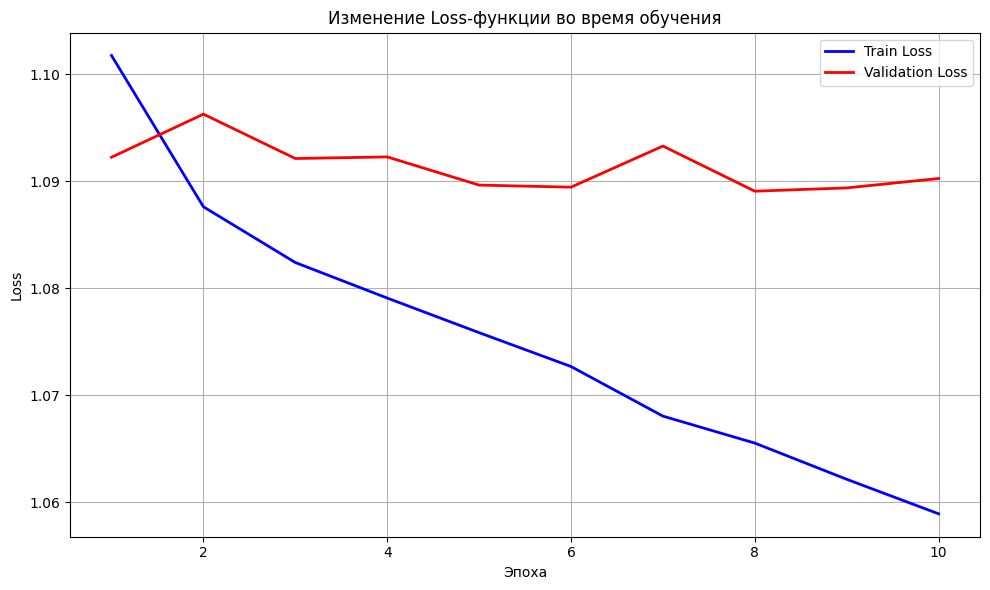


Финальные значения Loss:
Train Loss: 1.0589
Validation Loss: 1.0902


In [176]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
if 'val_loss' in history and len(history['val_loss']) > 0:
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)

plt.title('Изменение Loss-функции во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nФинальные значения Loss:")
print(f"Train Loss: {history['train_loss'][-1]:.4f}")
if 'val_loss' in history and len(history['val_loss']) > 0:
    print(f"Validation Loss: {history['val_loss'][-1]:.4f}")
